In [1]:
import yfinance as yf
import pandas as pd
import mplfinance as mpf
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from fredapi import Fred
import numpy as np

In [2]:
pip install ta

Note: you may need to restart the kernel to use updated packages.


In [3]:
start_date = dt.datetime(2014, 1, 1)
end_date = dt.datetime(2025, 12, 31)
stock_symbol = "^GSPC"

df = yf.download(stock_symbol, start=start_date, end=end_date, auto_adjust=True)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[["Open", "High", "Low", "Close", "Volume"]]
df = df.dropna()
df["adj_close"] = df["Close"]
df.head(5)


[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume,adj_close
Date,,,,,,
2014-01-02,1845.859985,1845.859985,1827.739990,1831.979980,3080600000,1831.979980
2014-01-03,1833.209961,1838.239990,1829.130005,1831.369995,2774270000,1831.369995
2014-01-06,1832.310059,1837.160034,1823.729980,1826.770020,3294850000,1826.770020
2014-01-07,1828.709961,1840.099976,1828.709961,1837.880005,3511750000,1837.880005
2014-01-08,1837.900024,1840.020020,1831.400024,1837.489990,3652140000,1837.489990


**Feature Engineering**

In [4]:
df["return_1d"] = df["adj_close"].pct_change()

# if its 1 price goes up tomorrow, if its 0 price go down tomorrow
df["target"] = (df["return_1d"].shift(-1)>0).astype(int)

In [5]:
df["return_5d"] = df["adj_close"].pct_change(5) 
df["return_10d"] = df["adj_close"].pct_change(10)
df["return_20d"] = df["adj_close"].pct_change(20)

df["volatility_10d"] = df["return_1d"].rolling(10).std() #short_term
df["volatility_20d"] = df["return_1d"].rolling(20).std() #medium_term
df["volatility_60d"] = df["return_1d"].rolling(60).std() #long_term

df["sma_10"] = df["adj_close"].rolling(10).mean() #simple Moving Average
df["sma_50"] = df["adj_close"].rolling(50).mean()
df["sma_200"] = df["adj_close"].rolling(200).mean()

df["sma_ratio_10_50"] = df["sma_10"] / df["sma_50"]
df["sma_ratio_50_200"] = df["sma_50"] / df["sma_200"]

df["volume_change"] = df["Volume"].pct_change()
df["volume_ma_20"] = df["Volume"].rolling(20).mean()
df["volume_ratio"] = df["Volume"] / df["volume_ma_20"]
df = df.dropna()
df.head()

Price,Open,High,Low,Close,Volume,adj_close,return_1d,target,return_5d,return_10d,...,volatility_20d,volatility_60d,sma_10,sma_50,sma_200,sma_ratio_10_50,sma_ratio_50_200,volume_change,volume_ma_20,volume_ratio
Date,,,,,,,,,,,,,,,,,,,,,
2014-10-16,1855.949951,1876.010010,1835.020020,1862.760010,5073150000,1862.760010,0.000145,1,-0.033943,-0.042859,...,0.010147,0.007568,1914.873987,1967.728000,1905.749048,0.973140,1.032522,-0.167080,4.027214e+09,1.259717
2014-10-17,1864.910034,1898.160034,1864.910034,1886.760010,4482120000,1886.760010,0.012884,1,-0.010162,-0.041232,...,0.010795,0.007777,1906.759985,1967.271802,1906.022948,0.969241,1.032134,-0.116502,4.007308e+09,1.118486
2014-10-20,1885.619995,1905.030029,1882.300049,1904.010010,3331210000,1904.010010,0.009143,1,0.015613,-0.030949,...,0.011063,0.007864,1900.678992,1966.720203,1906.386148,0.966421,1.031648,-0.256778,4.006386e+09,0.831475
2014-10-21,1909.380005,1942.449951,1909.380005,1941.280029,3987090000,1941.280029,0.019574,0,0.033861,0.003194,...,0.012047,0.008284,1901.296997,1966.807402,1906.958698,0.966692,1.031384,0.196889,4.041772e+09,0.986471
2014-10-22,1941.290039,1949.310059,1926.829956,1927.109985,3761930000,1927.109985,-0.007299,1,0.034695,-0.021220,...,0.011939,0.008316,1897.118994,1966.674602,1907.404848,0.964633,1.031074,-0.056472,4.064176e+09,0.925632


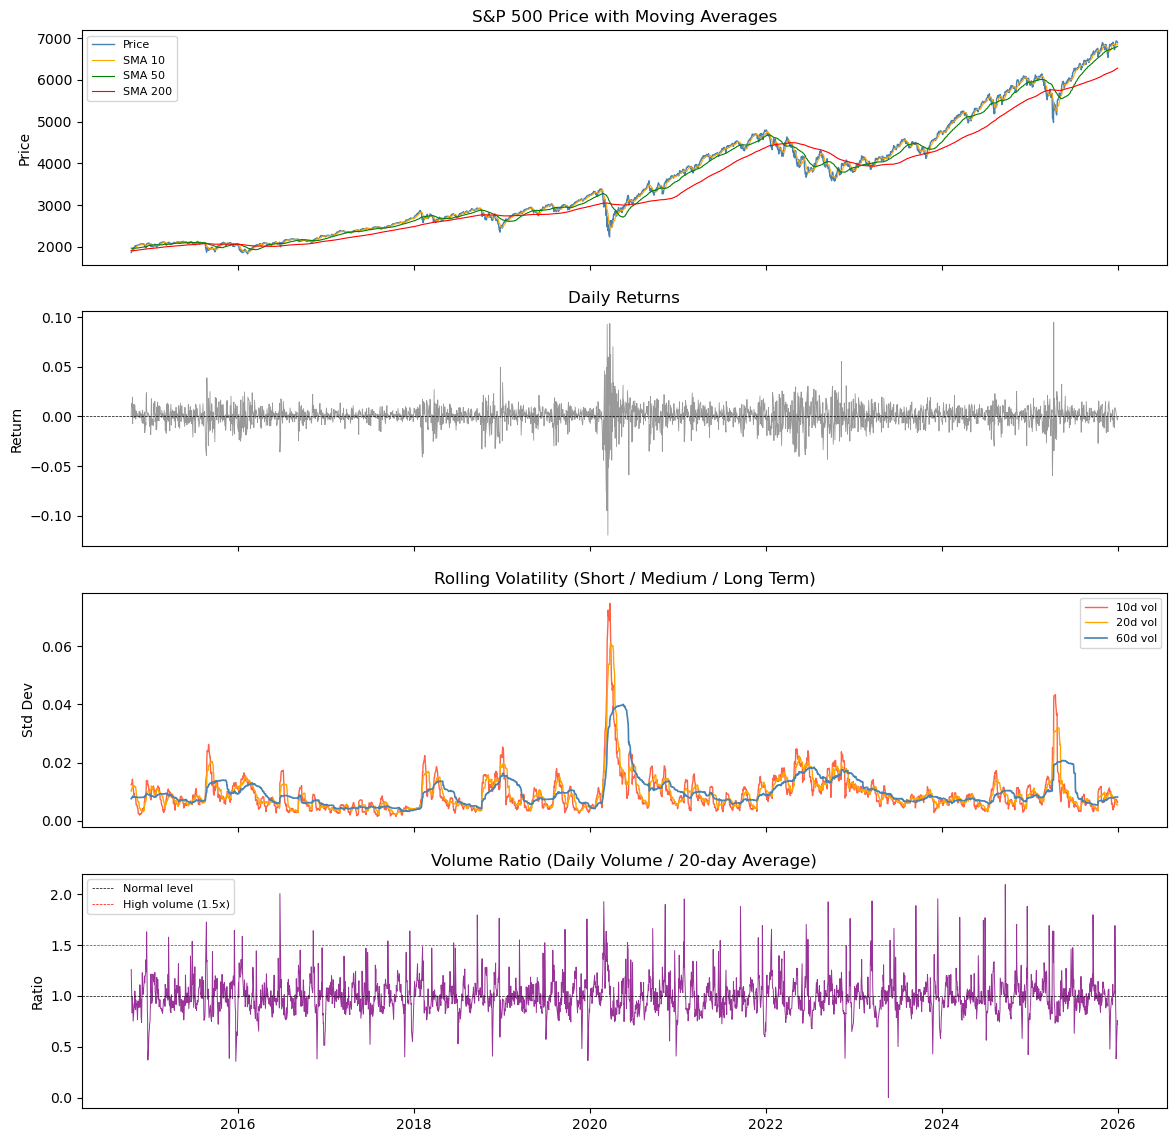

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# Chart 1: Price + SMAs
axes[0].plot(df.index, df["adj_close"], color="steelblue", linewidth=1, label="Price")
axes[0].plot(df.index, df["sma_10"],  color="orange", linewidth=0.8, label="SMA 10")
axes[0].plot(df.index, df["sma_50"],  color="green",  linewidth=0.8, label="SMA 50")
axes[0].plot(df.index, df["sma_200"], color="red",    linewidth=0.8, label="SMA 200")
axes[0].set_title("S&P 500 Price with Moving Averages", fontsize=12)
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left", fontsize=8)

# Chart 2: Daily returns
axes[1].plot(df.index, df["return_1d"], color="gray", linewidth=0.6, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_title("Daily Returns", fontsize=12)
axes[1].set_ylabel("Return")

# Chart 3: Rolling volatility
axes[2].plot(df.index, df["volatility_10d"], label="10d vol", color="tomato",    linewidth=1)
axes[2].plot(df.index, df["volatility_20d"], label="20d vol", color="orange",    linewidth=1)
axes[2].plot(df.index, df["volatility_60d"], label="60d vol", color="steelblue", linewidth=1.2)
axes[2].set_title("Rolling Volatility (Short / Medium / Long Term)", fontsize=12)
axes[2].set_ylabel("Std Dev")
axes[2].legend(fontsize=8)

# Chart 4: Volume ratio
axes[3].plot(df.index, df["volume_ratio"], color="purple", linewidth=0.7, alpha=0.8)
axes[3].axhline(1.0, color="black",  linewidth=0.5, linestyle="--", label="Normal level")
axes[3].axhline(1.5, color="red",    linewidth=0.5, linestyle="--", label="High volume (1.5x)")
axes[3].set_title("Volume Ratio (Daily Volume / 20-day Average)", fontsize=12)
axes[3].set_ylabel("Ratio")
axes[3].legend(fontsize=8)


**Chart 1 — Price with Moving Averages:**
The chart plots the S&P 500 price alongside SMA 10, SMA 50, and SMA 200. The SMA 200 (red) is the slowest and smoothest, acting as the long term trend line. The COVID crash in early 2020 is the most visible dip. The sma_ratio features capture when short term averages cross above or below the long term average, which XGBoost uses as a bullish or bearish signal.

**Chart 2 — Daily Returns:**
Each bar shows the percentage price change for that day. Most days sit near zero but the March 2020 COVID crash produced a return below negative 10%, the largest in the entire dataset. This confirms that extreme events occur more often than a normal distribution would predict, which is why volatility features are essential rather than assuming constant risk.

**Chart 3 — Rolling Volatility:**
The three lines measure return fluctuations over 10, 20, and 60 day windows. The 10 day line reacts fastest while the 60 day line stays elevated long after a crisis passes. The COVID spike reaching nearly 7% daily standard deviation is clearly visible. These features are the primary inputs the Hidden Markov Model uses in Stage 2 to classify each day as Bull, Bear, or High Volatility.

**Chart 4 — Volume Ratio:**
Daily volume divided by its 20 day average shows when trading activity is unusually high. Spikes above 1.5 cluster around the same stress periods seen in the volatility chart, confirming that volume surges during uncertainty. This helps the model distinguish between price moves backed by strong conviction versus low volume noise that tends to reverse.

**Relative Strength Index(RSI)**

In [7]:
#calculate the price differences
delta = df["adj_close"].diff()

gain = delta.clip(lower=0) # keeps the positive moves and turn all negative to 0
loss = -delta.clip(upper=0) # keeps the negative moves and turn all postive to 0

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

# Relative Strength
rs = avg_gain/avg_loss
df["rsi_14"] = 100 - (100/(1 + rs))
df.head()

Price,Open,High,Low,Close,Volume,adj_close,return_1d,target,return_5d,return_10d,...,volatility_60d,sma_10,sma_50,sma_200,sma_ratio_10_50,sma_ratio_50_200,volume_change,volume_ma_20,volume_ratio,rsi_14
Date,,,,,,,,,,,,,,,,,,,,,
2014-10-16,1855.949951,1876.010010,1835.020020,1862.760010,5073150000,1862.760010,0.000145,1,-0.033943,-0.042859,...,0.007568,1914.873987,1967.728000,1905.749048,0.973140,1.032522,-0.167080,4.027214e+09,1.259717,NaN
2014-10-17,1864.910034,1898.160034,1864.910034,1886.760010,4482120000,1886.760010,0.012884,1,-0.010162,-0.041232,...,0.007777,1906.759985,1967.271802,1906.022948,0.969241,1.032134,-0.116502,4.007308e+09,1.118486,NaN
2014-10-20,1885.619995,1905.030029,1882.300049,1904.010010,3331210000,1904.010010,0.009143,1,0.015613,-0.030949,...,0.007864,1900.678992,1966.720203,1906.386148,0.966421,1.031648,-0.256778,4.006386e+09,0.831475,NaN
2014-10-21,1909.380005,1942.449951,1909.380005,1941.280029,3987090000,1941.280029,0.019574,0,0.033861,0.003194,...,0.008284,1901.296997,1966.807402,1906.958698,0.966692,1.031384,0.196889,4.041772e+09,0.986471,NaN
2014-10-22,1941.290039,1949.310059,1926.829956,1927.109985,3761930000,1927.109985,-0.007299,1,0.034695,-0.021220,...,0.008316,1897.118994,1966.674602,1907.404848,0.964633,1.031074,-0.056472,4.064176e+09,0.925632,NaN


RSI is a momentum oscillator used to identify overbought or oversold conditions by measuring the speed and change of price movements.

**Formula**
$$RS = \frac{\text{Average Gain}}{\text{Average Loss}}$$$$RSI = 100 - \left( \frac{100}{1 + RS} \right)$$

In the context of your XGBoost model, the RSI serves as a bounded feature that captures market microstructure dynamics. While raw prices trend, the RSI is stationary, which is computationally essential for gradient boosted trees to identify patterns without being skewed by the scale of the stock price.

**Moving Average Convergence Divergence(MACD)**

In [8]:
import ta

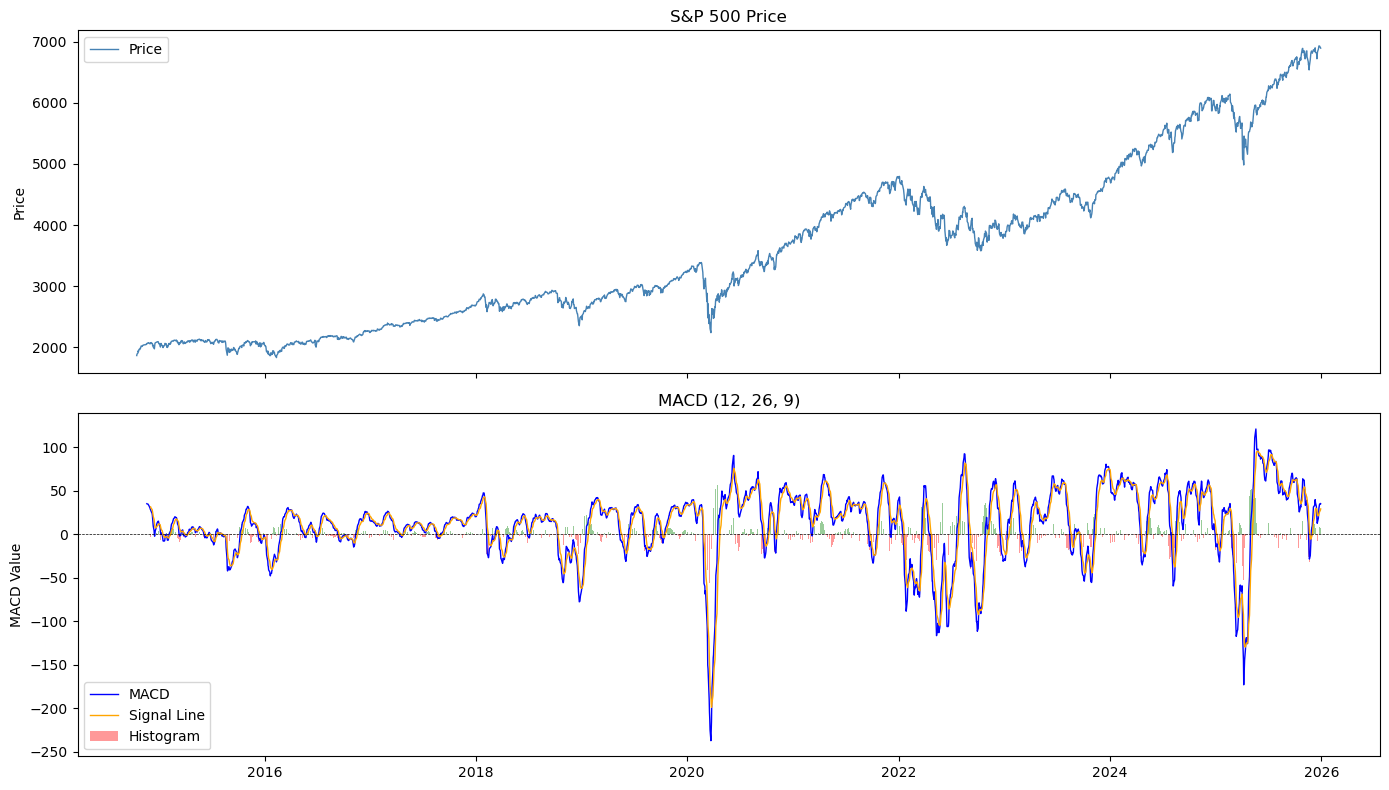

In [9]:
#MACD
macd = ta.trend.MACD(close = df["adj_close"], window_slow=26, window_fast=12, window_sign = 9)

df["macd"] = macd.macd()
df["macd_signal"] = macd.macd_signal()
df["macd_hist"] = macd.macd_diff()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Chart 1: Price
axes[0].plot(df.index, df["adj_close"], color="steelblue", linewidth=1, label="Price")
axes[0].set_title("S&P 500 Price", fontsize=12)
axes[0].set_ylabel("Price")
axes[0].legend()

# Chart 2: MACD
axes[1].plot(df.index, df["macd"],        color="blue",   linewidth=1,   label="MACD")
axes[1].plot(df.index, df["macd_signal"], color="orange", linewidth=1,   label="Signal Line")
axes[1].bar(df.index,  df["macd_hist"],   color=["green" if v >= 0 else "red" for v in df["macd_hist"]], 
            alpha=0.4, label="Histogram")
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_title("MACD (12, 26, 9)", fontsize=12)
axes[1].set_ylabel("MACD Value")
axes[1].legend()

plt.tight_layout()
plt.show()

The MACD indicator tracks the difference between the 12 day and 26 day exponential moving averages with a 9 day signal line sitting on top. The reason we use it is simple price alone does not tell you whether momentum is building or fading, but MACD does. When the blue MACD line crosses above the signal line the histogram turns green signaling bullish momentum, and when it drops below it turns red signaling bearish pressure. Looking at the chart, the most dramatic moment is the COVID crash in early 2020 where MACD plunged to nearly 250 on the downside, the largest reading in the entire 10 year dataset, followed by a sharp recovery as markets rebounded. The 2022 rate hike period also shows a sustained negative reading reflecting the prolonged selloff that year. For this project MACD gives XGBoost three separate inputs which are the MACD value, the signal line, and the histogram, and together they help the model detect shifts in momentum direction and strength across different market regimes rather than just reacting to raw price moves.

**Bollinger Bands**

In [10]:
bb = ta.volatility.BollingerBands(close=df["adj_close"], window = 20, window_dev=2)

df["bb_high"]=bb.bollinger_hband()
df["bb_low"]=bb.bollinger_lband()
df["bb_middle"]=bb.bollinger_mavg()
df["bollinger_width"]=bb.bollinger_wband()

Bollinger Bands place a upper and lower boundary around price based on how volatile the market is. The middle band is a 20 day simple moving average, and the upper and lower bands sit 2 standard deviations above and below it.


**Formula**
$$\text{Middle Band} = \text{SMA}_{20}$$$$\text{Upper Band} = \text{SMA}_{20} + 2\sigma_{20}$$$$\text{Lower Band} = \text{SMA}_{20} - 2\sigma_{20}$$$$\text{Band Width} = \frac{\text{Upper} - \text{Lower}}{\text{Middle}}$$

**Average True Range(ATR)**

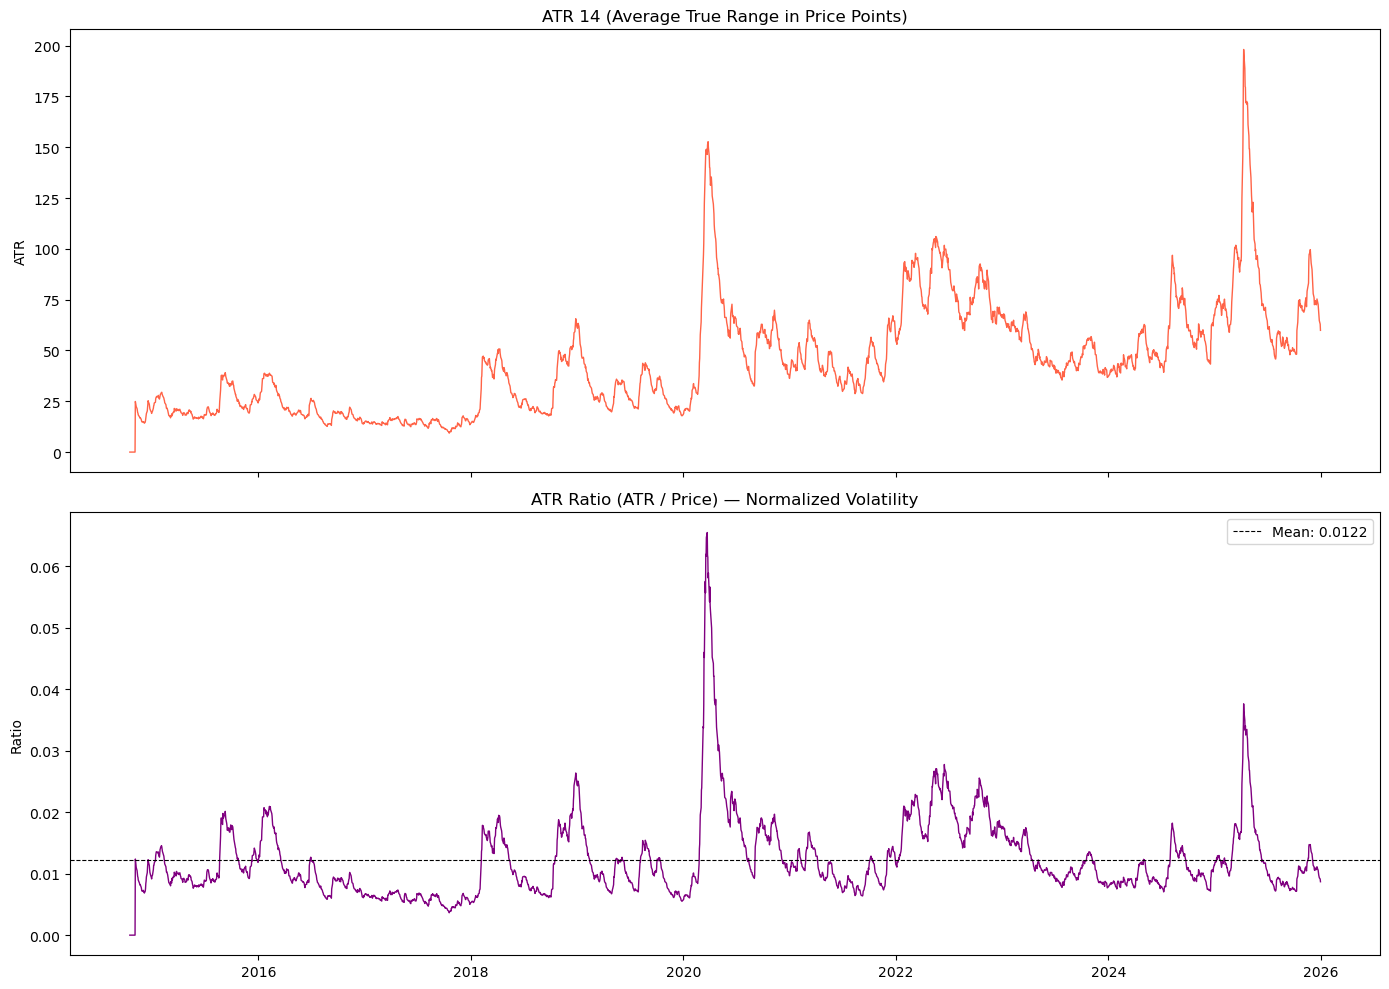

In [11]:
atr = ta.volatility.AverageTrueRange(high=df["High"], low=df["Low"], close=df["adj_close"], window=14)

df["atr_14"]=atr.average_true_range()
df["atr_ratio"]=df["atr_14"]/df["adj_close"]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df["atr_14"], color="tomato", linewidth=1)
axes[0].set_title("ATR 14 (Average True Range in Price Points)", fontsize=12)
axes[0].set_ylabel("ATR")

axes[1].plot(df.index, df["atr_ratio"], color="purple", linewidth=1)
axes[1].axhline(df["atr_ratio"].mean(), color="black", linewidth=0.8, 
                linestyle="--", label=f'Mean: {df["atr_ratio"].mean():.4f}')
axes[1].set_title("ATR Ratio (ATR / Price) — Normalized Volatility", fontsize=12)
axes[1].set_ylabel("Ratio")
axes[1].legend()

plt.tight_layout()
plt.show()

The Average True Range (ATR) measures the absolute daily "swing" of a stock's price in dollars, which naturally increases as the asset becomes more expensive over time. The ATR Ratio solves this by normalizing the data, dividing the volatility by the current price to show movement as a percentage of value rather than just a dollar amount. In these graphs, while the top chart shows volatility reaching high nominal levels in 2025, the bottom chart reveals that the "true" relative volatility is actually much lower than the 2020 peak, providing a stationary feature that helps your model identify genuine market stress regardless of the price level.

$$\text{ATR Ratio} = \frac{\text{ATR}_n}{\text{Price}_t}$$

**Fred Macro Data**

In [12]:
# VIXCLS = VIX
# FEDFUNDS = Federal Funds Rate
# CPIAUCSL = CPI
# T10Y2Y = 10-year minus 2-year yield spread

#FRED APIx
fred = Fred(api_key='a9b081012bd4ab8c6bc9f223fcff3bea')

# Pull macro series
vix          = fred.get_series("VIXCLS",    start_date, end_date)
fedfunds     = fred.get_series("FEDFUNDS",  start_date, end_date)
cpi          = fred.get_series("CPIAUCSL",  start_date, end_date)
yield_spread = fred.get_series("T10Y2Y",    start_date, end_date)

# Build macro dataframe
macro = pd.DataFrame({
    "vix":          vix,
    "fedfunds":     fedfunds,
    "cpi":          cpi,
    "yield_spread": yield_spread
})
macro.index = pd.to_datetime(macro.index)
macro = macro.sort_index()
macro = macro.ffill()

# SAFE MERGE (prevents duplicate columns on re-run)
# Drop all _x / _y leftover columns first
df = df.drop(columns=[c for c in df.columns if c.endswith("_x") or c.endswith("_y")])

# Drop clean macro cols if they already exist
macro_cols = ["vix", "fedfunds", "cpi", "yield_spread"]
df = df.drop(columns=[c for c in macro_cols if c in df.columns])

# Merge
df = df.merge(macro, left_index=True, right_index=True, how="left")

# Forward fill gaps (CPI and FEDFUNDS are monthly — fills non-release days)
df[macro_cols] = df[macro_cols].ffill()

# DERIVED MACRO FEATURES
df["vix_change"] = df["vix"].pct_change()
df["cpi_yoy"] = df["cpi"].pct_change(252) # year over year inflation rate
df["real_rate"] = df["fedfunds"] - df["cpi"].pct_change(252) * 100  # real interest rate
df["yield_spread_change"] = df["yield_spread"].diff()
df["vix_ma_20"] = df["vix"].rolling(20).mean()

# FINAL CLEANUP
df = df.dropna()

#Save final modeling dataset
df.to_csv("final_modeling_dataset.csv")

# VERIFY 
print(f"Shape: {df.shape}")
print(f"Nulls: {df.isnull().sum().sum()}")
df.head(5)

Shape: (2566, 41)
Nulls: 0


,Open,High,Low,Close,Volume,adj_close,return_1d,target,return_5d,return_10d,...,atr_ratio,vix,fedfunds,cpi,yield_spread,vix_change,cpi_yoy,real_rate,yield_spread_change,vix_ma_20
Date,,,,,,,,,,,,,,,,,,,,,
2015-10-16,2024.369995,2033.540039,2020.459961,2033.109985,3595430000,2033.109985,0.004570,1,0.009043,0.041894,...,0.013446,15.05,0.12,237.733,1.43,-0.062305,0.001276,-0.007617,0.00,20.4530
2015-10-19,2031.729980,2034.449951,2022.310059,2033.660034,3287320000,2033.660034,0.000271,0,0.008030,0.023457,...,0.012908,14.98,0.12,237.733,1.43,-0.004651,0.001276,-0.007617,0.00,20.1950
2015-10-20,2033.130005,2039.119995,2026.609985,2030.770020,3331500000,2030.770020,-0.001421,0,0.013515,0.025683,...,0.012443,15.75,0.12,237.733,1.42,0.051402,0.001276,-0.007617,-0.01,19.8605
2015-10-21,2033.469971,2037.969971,2017.219971,2018.939941,3627790000,2018.939941,-0.005825,1,0.012386,0.011579,...,0.012356,16.70,0.12,237.733,1.40,0.060317,0.001276,-0.007617,-0.02,19.5890
2015-10-22,2021.880005,2055.199951,2021.880005,2052.510010,4430850000,2052.510010,0.016628,1,0.014156,0.019410,...,0.012548,14.45,0.12,237.733,1.43,-0.134731,0.001276,-0.007617,0.03,19.1380
